**Author: Amey Sunil Sadegaonkar
Project: Book Reccommendation System**

- This Notebook is Part of abovementioned Project
- Following are the Objectives for this Notebook

## Objectives: 

- Theory odf Collaborative Filtering
- Model Based approach of Collaborative Filtering - Matrix Factorization approaches
    - Non-negetive Matrix Factorization (NMF) Model
    - Singular Value Decomposition (SVD) Model

=========================================================================================================================

### Necessary Libraries and Modules

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

### Loading UserRatings Dataset (cleaned)

In [2]:
ratings= pd.read_csv("C://Users//ameys//Desktop//CDAC//69618_amey//CDAC_Project//project_books_reco/UserRatingsData_cleaned.csv")

In [3]:
ratings.sample(10)

,UserID,BookName,UserRatingBook
267313,7020,Hamlet,4
257192,9642,A Short History of Nearly Everything,5
163535,3897,740 Park: The Story of the World's Richest Apa...,5
261152,9012,سمفونی مردگان,4
116253,2597,Three Days Missing,3
273079,8483,The Velveteen Rabbit,5
140011,3357,Homegoing,4
348407,9701,"Divine By Mistake (Partholon, #1)",3
122187,3073,The Double Bind,3
3078,53,Guide to Analysing Companies,4


### Loading Books Dataset (cleaned)

In [4]:
books=  pd.read_csv("C://Users//ameys//Desktop//CDAC//69618_amey//CDAC_Project//project_books_reco/BooksData_cleaned_RecSys.csv")

In [5]:
books.sample(10)

,BookID,BookTitle,Authors,Language,AverageRating,1StarRatingCount,2StarRatingCount,3StarRatingCount,4StarRatingCount,5StarRatingCount,TotalRatingCount,PageCount,Publisher,PublishYear,Description
123968,2209345,Twelfth Night (The Graphic Shakespeare Series),Hilary Burningham,eng,4.00,0,0,1,0,1,2,64,MMS Gold,1998-01-01,The books in this series provide support mater...
96531,1344065,"Andromeda Stories, Vol. 2",Keiko Takemiya,eng,3.42,1,11,21,19,10,62,208,Vertical,2007-01-01,The machine race known only as the Enemy has s...
81169,1002542,Midnight in the Garden of Good and Evil,John Berendt,eng,3.92,2889,10908,50880,86131,64105,214913,388,Random House,1994-01-01,Shots rang out in Savannah's grandest mansion ...
28618,231823,I Take This Man,Valerie Frankel,eng,3.23,28,70,152,93,63,406,320,William Morrow Paperbacks,2007-01-01,I Take This Man
27835,223937,Enterprise Security Architecture: A Business-D...,John Sherwood,eng,3.98,2,2,8,26,17,55,587,CRC Press,2005-01-01,Enterprise Security Architecture: A Business-D...
47683,469958,Burning Bright,Helen Dunmore,eng,3.76,9,28,125,207,97,466,263,Penguin,1995-01-01,Burning Bright
66549,762098,"Civilization and Capitalism 15th-18th Century,...",Fernand Braudel,eng,4.41,2,8,43,134,242,429,670,University of California Press,1992-01-01,The subject of The Wheels of Commerce is the d...
45225,432311,Thomas Jefferson: A Life,Willard Sterne Randall,eng,4.09,15,51,227,478,485,1256,736,Harper Perennial Modern Classics,2014-01-01,Thomas Jefferson: A Life
59287,641632,Doctor Who: City at World's End,Christopher Bulis,eng,3.52,4,15,52,70,18,159,288,BBC Worldwide Publishing,1999-01-01,The Doctor and his companions land in the city...
107548,1674085,Frank Lloyd Wright y Georgia O'Keeffe,Llorenc Bonet,eng,2.00,0,1,0,0,0,1,95,Hk Books,2003-01-01,"Arguably America's best-known architect, Frank..."


=========================================================================================================================

### 1.0. Collaborative Filtering - Theory

- It is considered to be one of the very smart recommender systems that work on the similarity between **different users** and also **different items** that are that are oftenly used in the industry on which recommendation sytem is based upon. 

- It checks about the taste of similar users and makes recommendations. eg. If User U likes movies M,N,O and if history of User V is similar to User U then it is highly likely that user V will also like Movies M,N,O so they will be recommended to V.

- The similarity is not restricted to the taste of the user, it can be based on different items also. eg. If user U likes Movies M, N then U may like movie O which is similarily rated by other users as M and N, So we can recommend Movie O to user U.

- The system will give more efficient recommendations if we have a large volume of information about users and items. There are various types of collaborative filtering techniques as mentioned in the diagram given below.

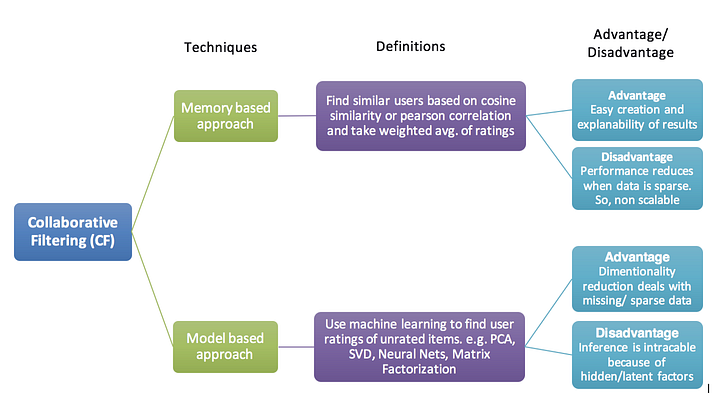

##### Types of collaborative filtering approaches

**Model Based Approach:**

- Model-based recommendation systems are created by building a model based on the dataset of ratings given to the items by its various users.
- Generally we try to extract some kind of information from the user-ratings dataset, and use that information as a “model” to make recommendations for other items without having to use the complete dataset every time. 
- This approach potentially offers the benefits of both speed and scalability.


- Model based collaborative approaches only rely on user-item interactions information and it assume a latent model supposed to explain these interactions. e.g. In matrix factorisation algorithms, we try to decomposing the huge and sparse user-item interaction matrix into a product of two smaller and dense matrices: a user-factor matrix (containing users representations) that multiplies a factor-item matrix (containing items representations).


- So we can say that the Model based approach involves building machine learning algorithms to predict user’s ratings.


=========================================================================================================================

### Collaborative Filtering Model

- We are basically plotting each book in n-dimentional user space
- Each dimension of space is a user and according to ratings given by users we are assigning point to the book in n-dimensional space

- But we taking some prerequisites for the user-book interactions for our recommendation system as follows
    - active users: consider users which rated certain number of books at minimum lets say 200
    - Famous books: books which at least got certain number of votes at minimum lets say 50
- We are doing this to get more valid data.

In [6]:
ratings1 = ratings.rename(columns={'BookName':'BookTitle'})
ratings1

,UserID,BookTitle,UserRatingBook
0,1,Agile Web Development with Rails: A Pragmatic ...,5
1,1,The Restaurant at the End of the Universe (Hit...,5
2,1,Siddhartha,5
3,1,The Clock of the Long Now: Time and Responsibi...,4
4,1,"Ready Player One (Ready Player One, #1)",4
...,...,...,...
357391,10978,The Foundation: A Great American Secret: How P...,3
357392,10986,Cosette: The Sequel to Les Miserables,4
357393,10986,J. D. Salinger's The Catcher in the Rye,5
357394,10988,Facing the Lion: Growing Up Maasai on the Afri...,3


In [7]:
ratings1 = ratings1.merge(books,how='left', on='BookTitle').drop_duplicates('BookTitle')[['BookTitle', 'Authors']]

In [8]:
ratings1

,BookTitle,Authors
0,Agile Web Development with Rails: A Pragmatic ...,Dave Thomas
1,The Restaurant at the End of the Universe (Hit...,Douglas Adams
3,Siddhartha,Hermann Hesse
5,The Clock of the Long Now: Time and Responsibi...,NaN
6,"Ready Player One (Ready Player One, #1)",NaN
...,...,...
618907,The Age of Kali: Indian Travels & Encounters,William Dalrymple
618908,Story-Wallah: Short Fiction from South Asian W...,Shyam Selvadurai
618909,The Foundation: A Great American Secret: How P...,NaN
618912,Facing the Lion: Growing Up Maasai on the Afri...,NaN


In [9]:
# Getting active_users list
x = ratings.groupby('UserID').count()['UserRatingBook']>200
active_users = x[x].index
active_users

Int64Index([    1,     5,    14,    21,    55,    73,   166,   182,   185,
              192,
            ...
            10705, 10706, 10725, 10745, 10778, 10848, 10857, 10891, 10936,
            10978],
           dtype='int64', name='UserID', length=467)

In [10]:
# filter the ratings with only active users
filtered_ratings = ratings[ratings['UserID'].isin(active_users)]

In [11]:
filtered_ratings

,UserID,BookName,UserRatingBook
0,1,Agile Web Development with Rails: A Pragmatic ...,5
1,1,The Restaurant at the End of the Universe (Hit...,5
2,1,Siddhartha,5
3,1,The Clock of the Long Now: Time and Responsibi...,4
4,1,"Ready Player One (Ready Player One, #1)",4
...,...,...,...
357387,10978,The Tenth Parallel: Dispatches from the Fault ...,4
357388,10978,India After Gandhi: The History of the World's...,4
357389,10978,The Age of Kali: Indian Travels & Encounters,4
357390,10978,Story-Wallah: Short Fiction from South Asian W...,4


In [12]:
# Getting famous_books
y = filtered_ratings.groupby('BookName').count()['UserRatingBook']>=50
famous_books = y[y].index
famous_books

Index(['11/22/63', '1984', 'A Christmas Carol',
       'A Clash of Kings (A Song of Ice and Fire, #2)', 'A Clockwork Orange',
       'A Confederacy of Dunces',
       'A Dance with Dragons (A Song of Ice and Fire, #5)',
       'A Discovery of Witches (All Souls Trilogy, #1)', 'A Farewell to Arms',
       'A Feast for Crows (A Song of Ice and Fire, #4)',
       ...
       'Where the Wild Things Are', 'Where'd You Go, Bernadette',
       'White Noise', 'White Teeth',
       'Wicked: The Life and Times of the Wicked Witch of the West (The Wicked Years, #1)',
       'Wild: From Lost to Found on the Pacific Crest Trail',
       'World War Z: An Oral History of the Zombie War', 'Wuthering Heights',
       'Yes Please', 'چراغ‌ها را من خاموش می‌کنم'],
      dtype='object', name='BookName', length=359)

In [13]:
# filter the ratings which only has active_users and famous_books i.e. our valid data
final_ratings = filtered_ratings[filtered_ratings['BookName'].isin(famous_books)]
final_ratings

,UserID,BookName,UserRatingBook
2,1,Siddhartha,5
4,1,"Ready Player One (Ready Player One, #1)",4
5,1,"The Hunger Games (The Hunger Games, #1)",5
12,1,The Name of the Rose,3
18,1,A Short History of Nearly Everything,5
...,...,...,...
313695,10309,"The Silence of the Lambs (Hannibal Lecter, #2)",4
313696,10331,"The Silence of the Lambs (Hannibal Lecter, #2)",3
313697,10378,"The Silence of the Lambs (Hannibal Lecter, #2)",5
313698,10778,"The Silence of the Lambs (Hannibal Lecter, #2)",4


In [14]:
# Creating User-Item interaction matrix
pivot = final_ratings.pivot_table(index='BookName',columns='UserID',
                                  values='UserRatingBook')
pivot

UserID,1,5,14,21,55,73,166,182,185,192,...,10705,10706,10725,10745,10778,10848,10857,10891,10936,10978
BookName,,,,,,,,,,,,,,,,,,,,,
11/22/63,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984,5.0,NaN,NaN,4.0,NaN,5.0,3.0,5.0,NaN,NaN,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN
A Christmas Carol,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,3.0,NaN,...,NaN,4.0,NaN,NaN,4.0,4.0,NaN,NaN,NaN,NaN
"A Clash of Kings (A Song of Ice and Fire, #2)",5.0,NaN,NaN,NaN,5.0,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN
A Clockwork Orange,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wild: From Lost to Found on the Pacific Crest Trail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
World War Z: An Oral History of the Zombie War,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,2.0,NaN,...,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
Wuthering Heights,NaN,NaN,NaN,NaN,NaN,NaN,5.0,4.0,NaN,NaN,...,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0,NaN


In [15]:
pivot.fillna(0,inplace=True)
pivot

UserID,1,5,14,21,55,73,166,182,185,192,...,10705,10706,10725,10745,10778,10848,10857,10891,10936,10978
BookName,,,,,,,,,,,,,,,,,,,,,
11/22/63,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,5.0,0.0,0.0,4.0,0.0,5.0,3.0,5.0,0.0,0.0,...,5.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0
A Christmas Carol,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,3.0,0.0,...,0.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0
"A Clash of Kings (A Song of Ice and Fire, #2)",5.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
A Clockwork Orange,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wild: From Lost to Found on the Pacific Crest Trail,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
World War Z: An Oral History of the Zombie War,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
Wuthering Heights,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,...,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0


In [16]:
# Creating Cosine Similarity matrix 
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores = cosine_similarity(pivot)
similarity_scores.shape

(359, 359)

In [17]:
# Creating Recommendation Function
def recommend(BookName):
    try:
        # index fetch
        index = np.where(pivot.index==BookName)[0][0]
        similar_items = sorted(list(enumerate(similarity_scores[index])),
                               key=lambda x:x[1],reverse=True)[1:6]

        data = []
        for i in similar_items:
            item = []
            temp_df = ratings1[ratings1['BookTitle'] == pivot.index[i[0]]]
            item.extend(
                list(temp_df.drop_duplicates('BookTitle')['BookTitle'].values))
            item.extend(
                list(temp_df.drop_duplicates('BookTitle')['Authors'].values))
            data.append(item)
    
        return data
    
    except:
        print("Book Not Found in Database")

-----

### Rough work

In [18]:
index = np.where(pivot.index=='World War Z: An Oral History of the Zombie War')[0][0]
index

355

In [19]:
similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:6]
similar_items

[(86, 0.4395194194037071),
 (287, 0.4349193727254067),
 (273, 0.41437203098702097),
 (259, 0.3984866869122337),
 (201, 0.38357320840718634)]

In [20]:
for i in similar_items:
            item = []
            temp_df = books[books['BookTitle'] == pivot.index[i[0]]]
            item.extend(list(temp_df.drop_duplicates('BookTitle')['BookTitle'].values))
            item.extend(list(temp_df.drop_duplicates('BookTitle')['Authors'].values))
            print(item)

["Ender's Game (Ender's Saga, #1)", 'Orson Scott Card']
['The Passage (The Passage, #1)', 'Justin Cronin']
[]
['The Hunger Games (The Hunger Games, #1)', 'Suzanne Collins']
['Snow Crash', 'Neal Stephenson']


In [21]:
temp_df = ratings[ratings['BookName'] == pivot.index[273]]
temp_df

,UserID,BookName,UserRatingBook
401,1,The Martian,5
562,3,The Martian,5
1404,8,The Martian,5
3278,55,The Martian,5
3481,56,The Martian,4
...,...,...,...
232964,10778,The Martian,5
232965,10792,The Martian,4
232966,10814,The Martian,5
232967,10848,The Martian,4


In [22]:
similarity_scores

array([[1.        , 0.20806639, 0.05820356, ..., 0.12276442, 0.20188975,
        0.        ],
       [0.20806639, 1.        , 0.34154346, ..., 0.45940636, 0.28692945,
        0.27487663],
       [0.05820356, 0.34154346, 1.        , ..., 0.32990051, 0.12842297,
        0.07786277],
       ...,
       [0.12276442, 0.45940636, 0.32990051, ..., 1.        , 0.20894643,
        0.15690262],
       [0.20188975, 0.28692945, 0.12842297, ..., 0.20894643, 1.        ,
        0.02629704],
       [0.        , 0.27487663, 0.07786277, ..., 0.15690262, 0.02629704,
        1.        ]])

In [23]:
for i in similar_items:
            item = []
            temp_df = ratings[ratings['BookName'] == pivot.index[i[0]]]
            item.extend(list(temp_df.drop_duplicates('BookName')['BookName'].values))
            #item.extend(list(temp_df.drop_duplicates('BookTitle')['Authors'].values))
            print(item)

["Ender's Game (Ender's Saga, #1)"]
['The Passage (The Passage, #1)']
['The Martian']
['The Hunger Games (The Hunger Games, #1)']
['Snow Crash']


-----

In [24]:
recommend('1984')

[['Animal Farm', 'George Orwell'],
 ['The Catcher in the Rye', 'J.D. Salinger'],
 ['Lord of the Flies', 'William Golding'],
 ['The Great Gatsby', 'F. Scott Fitzgerald'],
 ['Fahrenheit 451', 'Ray Bradbury']]

In [25]:
recommend('Wuthering Heights')

[['Jane Eyre', 'Charlotte Brontë'],
 ['Pride and Prejudice', 'Jane Austen'],
 ['Sense and Sensibility', 'Jane Austen'],
 ['The Catcher in the Rye', 'J.D. Salinger'],
 ['The Great Gatsby', 'F. Scott Fitzgerald']]

In [26]:
recommend('Amey')

Book Not Found in Database


In [27]:
recommend('World War Z: An Oral History of the Zombie War')

[["Ender's Game (Ender's Saga, #1)", 'Orson Scott Card'],
 ['The Passage (The Passage, #1)', 'Justin Cronin'],
 ['The Martian', nan],
 ['The Hunger Games (The Hunger Games, #1)', 'Suzanne Collins'],
 ['Snow Crash', 'Neal Stephenson']]

In [28]:
#import pickle
#pickle.dump(famous_books,open('famous_books1.pkl','wb'))

In [29]:
#pickle.dump(similarity_scores, open('similarity_scores1.pkl','wb'))
#pickle.dump(pivot, open('pivot1.pkl','wb'))
#pickle.dump(ratings1, open('ratings11.pkl','wb'))

==========================================================================

### Search Function

In [30]:
# Function to get Books containing partial name

def BookTitles_from_partialTitle(partial):
    for name in famous_books:
        if partial in name:
            print(name)

In [31]:
BookTitles_from_partialTitle("Harry Potter")

Harry Potter and the Chamber of Secrets (Harry Potter, #2)
Harry Potter and the Deathly Hallows (Harry Potter, #7)
Harry Potter and the Goblet of Fire (Harry Potter, #4)
Harry Potter and the Half-Blood Prince (Harry Potter, #6)
Harry Potter and the Order of the Phoenix (Harry Potter, #5)
Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)
Harry Potter and the Sorcerer's Stone (Harry Potter, #1)


In [32]:
BookTitles_from_partialTitle("bird")

To Kill a Mockingbird


In [33]:
BookTitles_from_partialTitle("Song of ")

A Clash of Kings (A Song of Ice and Fire, #2)
A Dance with Dragons (A Song of Ice and Fire, #5)
A Feast for Crows (A Song of Ice and Fire, #4)
A Game of Thrones (A Song of Ice and Fire, #1)
A Storm of Swords (A Song of Ice and Fire, #3)


In [34]:
BookTitles_from_partialTitle("Rings")

The Fellowship of the Ring (The Lord of the Rings, #1)
The Lord of the Rings (The Lord of the Rings, #1-3)
The Return of the King (The Lord of the Rings, #3)
The Two Towers (The Lord of the Rings, #2)


===========================================================================

### Top 50 Names

In [35]:
rating_count_df = ratings.groupby('BookName').count()['UserRatingBook'].reset_index()
rating_count_df.rename(columns={'BookName':'BookTitle','UserRatingBook':'ratings_count'},inplace=True)
rating_count_df

,BookTitle,ratings_count
0,!آنچه سینما هست,1
1,!از قر و قمبیل‌های قلمی بی‌قال و قیل,1
2,""" Talking Heads """,1
3,"""A Problem from Hell"": America and the Age of ...",11
4,"""A"" Is for Africa",1
...,...,...
103527,"달빛 조각사 8 (The Legendary Moonlight Sculptor, #8)",1
103528,"달빛 조각사 9 (The Legendary Moonlight Sculptor, #9)",1
103529,모리와 함께한 화요일,1
103530,흰,1


In [36]:
rating_avg_df = ratings.groupby('BookName').mean()['UserRatingBook'].reset_index()
rating_avg_df.rename(columns={'BookName':'BookTitle','UserRatingBook':'ratings_avg'},inplace=True)
rating_avg_df

,BookTitle,ratings_avg
0,!آنچه سینما هست,2.0
1,!از قر و قمبیل‌های قلمی بی‌قال و قیل,5.0
2,""" Talking Heads """,2.0
3,"""A Problem from Hell"": America and the Age of ...",4.0
4,"""A"" Is for Africa",3.0
...,...,...
103527,"달빛 조각사 8 (The Legendary Moonlight Sculptor, #8)",4.0
103528,"달빛 조각사 9 (The Legendary Moonlight Sculptor, #9)",4.0
103529,모리와 함께한 화요일,5.0
103530,흰,4.0


In [37]:
popular_df = rating_count_df.merge(rating_avg_df,on='BookTitle')
popular_df

,BookTitle,ratings_count,ratings_avg
0,!آنچه سینما هست,1,2.0
1,!از قر و قمبیل‌های قلمی بی‌قال و قیل,1,5.0
2,""" Talking Heads """,1,2.0
3,"""A Problem from Hell"": America and the Age of ...",11,4.0
4,"""A"" Is for Africa",1,3.0
...,...,...,...
103527,"달빛 조각사 8 (The Legendary Moonlight Sculptor, #8)",1,4.0
103528,"달빛 조각사 9 (The Legendary Moonlight Sculptor, #9)",1,4.0
103529,모리와 함께한 화요일,1,5.0
103530,흰,1,4.0


In [38]:
popular_df = popular_df[popular_df['ratings_count']>=250].sort_values('ratings_avg',ascending=False).head(50)
popular_df

,BookTitle,ratings_count,ratings_avg
29960,Harry Potter and the Deathly Hallows (Harry Po...,450,4.433333
76832,The Little Prince,371,4.347709
88852,To Kill a Mockingbird,829,4.317250
73232,"The Giver (The Giver, #1)",280,4.310714
1588,"A Game of Thrones (A Song of Ice and Fire, #1)",259,4.247104
74762,"The Hunger Games (The Hunger Games, #1)",458,4.220524
22886,"Ender's Game (Ender's Saga, #1)",340,4.211765
65326,The Amazing Adventures of Kavalier & Clay,310,4.209677
29974,Harry Potter and the Prisoner of Azkaban (Harr...,630,4.176190
60375,Slaughterhouse-Five,503,4.174950


In [39]:
popular_df = popular_df.merge(books,how='left', on='BookTitle').drop_duplicates('BookTitle')[['BookTitle','Authors','ratings_count','ratings_avg']]
popular_df = popular_df.reset_index(drop = 'True')
popular_df

,BookTitle,Authors,ratings_count,ratings_avg
0,Harry Potter and the Deathly Hallows (Harry Po...,J.K. Rowling,450,4.433333
1,The Little Prince,Antoine de Saint-Exupéry,371,4.347709
2,To Kill a Mockingbird,Harper Lee,829,4.317250
3,"The Giver (The Giver, #1)",Lois Lowry,280,4.310714
4,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,259,4.247104
5,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,458,4.220524
6,"Ender's Game (Ender's Saga, #1)",Orson Scott Card,340,4.211765
7,The Amazing Adventures of Kavalier & Clay,Michael Chabon,310,4.209677
8,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,630,4.176190
9,Slaughterhouse-Five,Kurt Vonnegut Jr.,503,4.174950


In [40]:
#pickle.dump(popular_df, open('top50books.pkl','wb'))

------

----